In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/matthew/ONS/intro_to_python/2011.csv', header = 1)

In [3]:
# Example of exisitng columns

df.head()

,Person ID,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,Health,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade
0,7394816,E12000001,H,2,1,2,6,2,2,1,2,1,2,5,8,2,-9,4
1,7394745,E12000001,H,5,1,1,4,1,2,1,1,1,2,1,8,6,4,3
2,7395066,E12000001,H,3,1,2,4,1,2,1,1,1,1,1,6,11,3,4
3,7395329,E12000001,H,3,1,2,2,1,2,1,2,1,2,1,7,7,3,2
4,7394712,E12000001,H,3,1,1,5,4,2,1,1,1,2,1,1,4,3,2


In [4]:
# Exploring the Sex column

df.groupby(["Sex"]).count()["Person ID"]

Sex
1    280569
2    289172
Name: Person ID, dtype: int64

In [5]:
# Setting up f_percent and m_percent column
# I used the sex_dict emthod form the Week 4 notes

sex_dict = {1: False, 2: True}

In [6]:
# Creating a 'Female' column

df['Female'] = df['Sex'].map(sex_dict)
df["Female"].head()

0     True
1    False
2     True
3     True
4    False
Name: Female, dtype: bool

In [7]:
# Filling in 'Male' column

df['Male'] = df['Sex'].map({1 : True, 2 : False})
df["Male"].head()

0    False
1     True
2    False
3    False
4     True
Name: Male, dtype: bool

In [8]:
#Creatign labels for the 'Economic Activity' column

eco_dict = {1 : "Active: Employee", 
            2 : "Active: Self-employed", 
            3 : "Active: Unemployed", 
            4 : "Active: Full-time student",
            5 : "Inactive: Retired", 
            6 : "Inactive: Student", 
            7 : "Inactive: Looking after home", 
            8 : "Inactive: Disabled",
            9 : "Inactive: Other",
            -9: "No code required"}

# Labelling 'Economic Activity' column

df['Eco. Activity Headers'] = df['Economic Activity'].map(eco_dict)
df["Eco. Activity Headers"].head()

0    Inactive: Retired
1     Active: Employee
2     Active: Employee
3     Active: Employee
4     Active: Employee
Name: Eco. Activity Headers, dtype: str

In [9]:
# Creating summations of Sex columns

df_sum = df[["Eco. Activity Headers", "Female", "Male"]] .groupby(["Eco. Activity Headers"]).sum()
df_sum

,Female,Male
Eco. Activity Headers,,
Active: Employee,108028,107997
Active: Full-time student,7530,6587
Active: Self-employed,11842,28790
Active: Unemployed,7349,10760
Inactive: Disabled,8769,9222
Inactive: Looking after home,16230,1715
Inactive: Other,5604,4464
Inactive: Retired,56875,40605
Inactive: Student,12136,12620


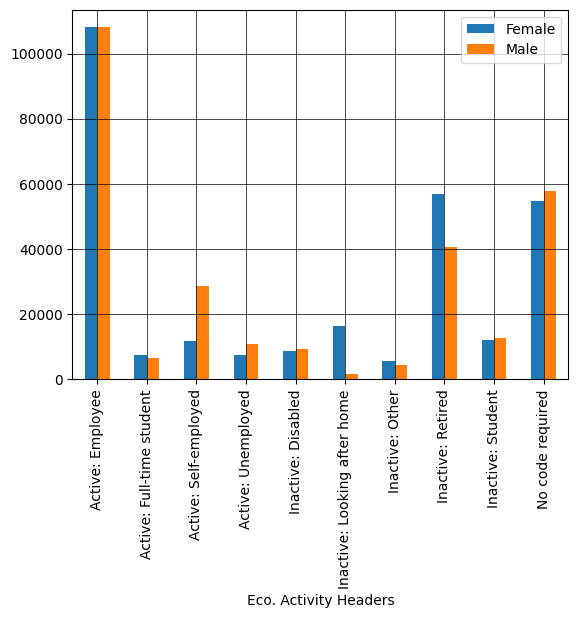

In [10]:
# Sex differences among unemployed employed and self-employed individuals 

df_sum.plot(kind = 'bar')
plt.grid(color = "k", linewidth = 0.5)

In [11]:
# Setting new headers for future plots

df["Sex Headers"] = df["Sex"].map({1 : "Female", 2 : "Male"})
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569741 entries, 0 to 569740
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Person ID                  569741 non-null  int64
 1   Region                     569741 non-null  str  
 2   Residence Type             569741 non-null  str  
 3   Family Composition         569741 non-null  int64
 4   Population Base            569741 non-null  int64
 5   Sex                        569741 non-null  int64
 6   Age                        569741 non-null  int64
 7   Marital Status             569741 non-null  int64
 8   Student                    569741 non-null  int64
 9   Country of Birth           569741 non-null  int64
 10  Health                     569741 non-null  int64
 11  Ethnic Group               569741 non-null  int64
 12  Religion                   569741 non-null  int64
 13  Economic Activity          569741 non-null  int64
 14  Occupation     

In [12]:
# 

active_ecos = df['Eco. Activity Headers'][df['Eco. Activity Headers'].str.startswith('Active')].unique()

list(active_ecos)

['Active: Employee',
 'Active: Full-time student',
 'Active: Self-employed',
 'Active: Unemployed']

In [13]:
# Restrict to economically active (1, 2, 3), using tools that we have before

df_active_eco_sex = df[df['Eco. Activity Headers'].isin(["Active: Employee", "Active: Self-employed", "Active: Unemployed", ])]
df_active_eco_sex.head()

,Person ID,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,...,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade,Female,Male,Eco. Activity Headers,Sex Headers
1,7394745,E12000001,H,5,1,1,4,1,2,1,...,2,1,8,6,4,3,False,True,Active: Employee,Female
2,7395066,E12000001,H,3,1,2,4,1,2,1,...,1,1,6,11,3,4,True,False,Active: Employee,Male
3,7395329,E12000001,H,3,1,2,2,1,2,1,...,2,1,7,7,3,2,True,False,Active: Employee,Male
4,7394712,E12000001,H,3,1,1,5,4,2,1,...,2,1,1,4,3,2,False,True,Active: Employee,Female
5,7394750,E12000001,H,2,1,1,6,2,2,1,...,1,1,9,2,3,3,False,True,Active: Employee,Female


In [14]:
# Grouping active population together by sex

gb_active_eco_sex = df_active_eco_sex.groupby(["Eco. Activity Headers", "Sex Headers"]).size().unstack()
gb_active_eco_sex

Sex Headers,Female,Male
Eco. Activity Headers,,
Active: Employee,107997,108028
Active: Self-employed,28790,11842
Active: Unemployed,10760,7349


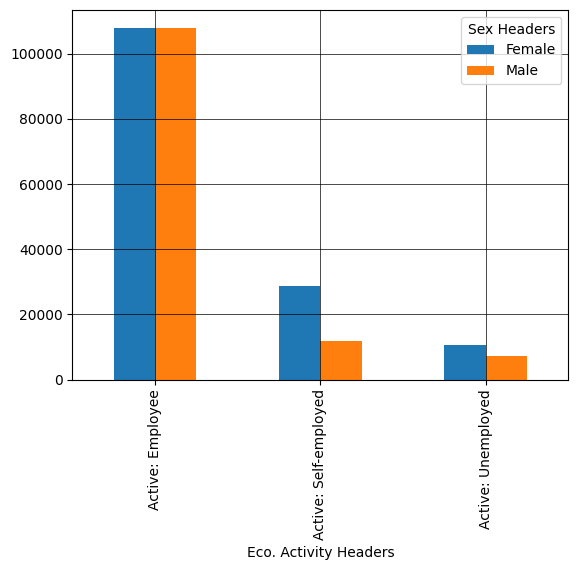

In [15]:
# Plot active people by sex

gb_active_eco_sex[["Female", "Male"]] .plot(kind = 'bar')
plt.grid(color = "k", linewidth = 0.5)

In [16]:
# Create sum column

gb_active_eco_sex["people_sum"] = gb_active_eco_sex["Female"] + gb_active_eco_sex["Male"]
gb_active_eco_sex

Sex Headers,Female,Male,people_sum
Eco. Activity Headers,,,
Active: Employee,107997,108028,216025
Active: Self-employed,28790,11842,40632
Active: Unemployed,10760,7349,18109


In [17]:
gb_active_eco_sex['F_percent'] = 100 * gb_active_eco_sex['Female']/gb_active_eco_sex['people_sum']
gb_active_eco_sex['M_percent'] = 100 * gb_active_eco_sex['Male']/gb_active_eco_sex['people_sum']
gb_active_eco_sex

Sex Headers,Female,Male,people_sum,F_percent,M_percent
Eco. Activity Headers,,,,,
Active: Employee,107997,108028,216025,49.992825,50.007175
Active: Self-employed,28790,11842,40632,70.855483,29.144517
Active: Unemployed,10760,7349,18109,59.417969,40.582031


In [18]:
# Textual representation of the data

pd.options.display.float_format = '{:.1f}'.format
gb_active_eco_sex[["F_percent", "M_percent"]]


Sex Headers,F_percent,M_percent
Eco. Activity Headers,,
Active: Employee,50.0,50.0
Active: Self-employed,70.9,29.1
Active: Unemployed,59.4,40.6


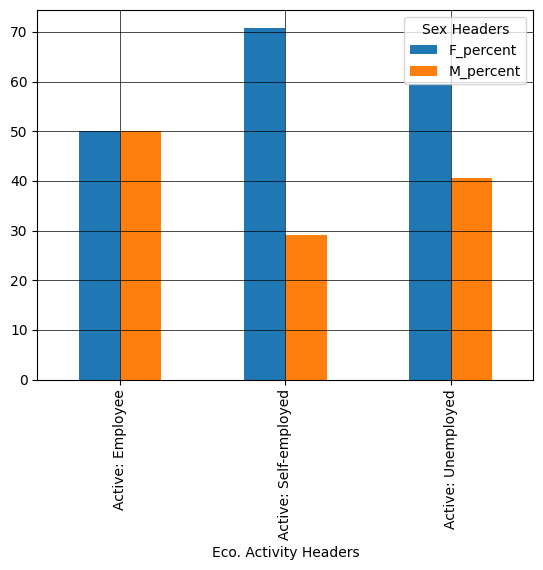

In [19]:
# Plot percentage fo each sex by activity

gb_active_eco_sex[['F_percent', 'M_percent']].plot(kind = 'bar')
plt.grid(color = "k", linewidth = 0.5)

In [20]:
# Figure 2 - dataframe setup

work_headers = {1: "15 or less",
                2: "16 to 30",
                3: "31 to 48",
                4: "49 or more"}

df['Work Hours Headers'] = df['Hours worked per week'].map(work_headers)
df["Work Hours Headers"]

0                NaN
1         49 or more
2           31 to 48
3           31 to 48
4           31 to 48
             ...    
569736      31 to 48
569737      31 to 48
569738           NaN
569739           NaN
569740    15 or less
Name: Work Hours Headers, Length: 569741, dtype: str

In [21]:
# Figure 2 - creating relevant dataframe

df_work_hrs_sex = df.dropna()
df_work_hrs_sex.shape

(267420, 23)

In [22]:
# Plotting function

def data_bar_chart(df, col_x, col_y, transpose = False):
    gb = df.groupby([col_x, col_y]).size().unstack()

    gb["person_sum"] = gb.sum(axis = 1)
    print(gb)
    
    for col in gb.columns.values:
        gb[col + " %"] = 100 *gb[col]/gb["person_sum"]
    print(gb.columns.values)

    percent_cols = [col for col in gb.columns.values if "%" in col and col != "person_sum %"]
    print(gb[percent_cols])
    
    if transpose == True:
        np.transpose(gb[percent_cols]).plot(kind = "bar")
    else:
        gb[percent_cols].plot(kind = "bar")

    plt.grid(color = "k", linewidth = 0.5)



Work Hours Headers  15 or less  16 to 30  31 to 48  49 or more  person_sum
Sex Headers                                                               
Female                    8345     13958     92044       27269      141616
Male                     17431     38175     61894        8304      125804
<StringArray>
[  '15 or less',     '16 to 30',     '31 to 48',   '49 or more',
   'person_sum', '15 or less %',   '16 to 30 %',   '31 to 48 %',
 '49 or more %', 'person_sum %']
Length: 10, dtype: str
Work Hours Headers  15 or less %  16 to 30 %  31 to 48 %  49 or more %
Sex Headers                                                           
Female                       5.9         9.9        65.0          19.3
Male                        13.9        30.3        49.2           6.6


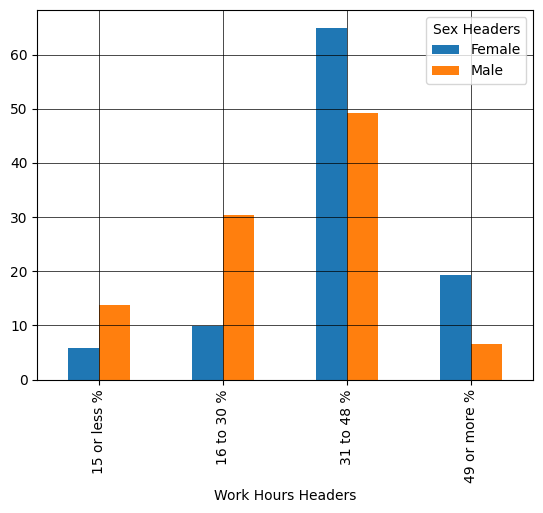

In [24]:
# Figure 2 - text representation adn chart

data_bar_chart(df_work_hrs_sex, "Sex Headers", "Work Hours Headers", transpose = True)

In [25]:
# Figure 3 - headers column

df_work_hrs_employed = df[df['Eco. Activity Headers'].isin(["Active: Employee", "Active: Self-employed", ])].dropna()
df_work_hrs_employed.info()

<class 'pandas.DataFrame'>
Index: 256657 entries, 1 to 569740
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Person ID                  256657 non-null  int64
 1   Region                     256657 non-null  str  
 2   Residence Type             256657 non-null  str  
 3   Family Composition         256657 non-null  int64
 4   Population Base            256657 non-null  int64
 5   Sex                        256657 non-null  int64
 6   Age                        256657 non-null  int64
 7   Marital Status             256657 non-null  int64
 8   Student                    256657 non-null  int64
 9   Country of Birth           256657 non-null  int64
 10  Health                     256657 non-null  int64
 11  Ethnic Group               256657 non-null  int64
 12  Religion                   256657 non-null  int64
 13  Economic Activity          256657 non-null  int64
 14  Occupation          

Work Hours Headers     15 or less  16 to 30  31 to 48  49 or more  person_sum
Eco. Activity Headers                                                        
Active: Employee            14908     42060    133708       25349      216025
Active: Self-employed        4403      7739     18547        9943       40632
<StringArray>
[  '15 or less',     '16 to 30',     '31 to 48',   '49 or more',
   'person_sum', '15 or less %',   '16 to 30 %',   '31 to 48 %',
 '49 or more %', 'person_sum %']
Length: 10, dtype: str
Work Hours Headers     15 or less %  16 to 30 %  31 to 48 %  49 or more %
Eco. Activity Headers                                                    
Active: Employee                6.9        19.5        61.9          11.7
Active: Self-employed          10.8        19.0        45.6          24.5


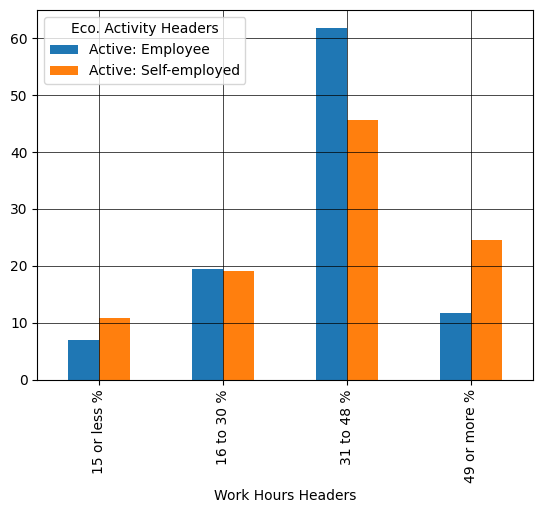

In [27]:
# Figure 3 - plotting

data_bar_chart(df_work_hrs_employed, "Eco. Activity Headers", "Work Hours Headers", transpose = True)

In [28]:
# Figure 4 - creating headers column

industry_headers = {1: "Agriculture, forestry and fishing", 
    2: "Mining and quarrying; Manufacturing; Electricity, gas, steam and air conditioning system; Water supply", 
 	3: "Construction", 
 	4: "Wholesale and retail trade; Repair of motor vehicles and motorcycles",
 	5: "Accommodation and food service activities", 
 	6: "Transport and storage; Information and communication", 
 	7: "Financial and insurance activities; Intermediation", 
 	8: "Real estate activities; Professional, scientific and technical activities; Administrative and support service activities", 
 	9: "Public administration and defence; compulsory social security", 
 	10: "Education", 
 	11: "Human health and social work activities", 
 	12: "Other community, social and personal service activities; Private households employing domestic staff; Extra-territorial organisations and bodies"}

df["Industry Headers"] = df["Industry"].map(industry_headers)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569741 entries, 0 to 569740
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Person ID                  569741 non-null  int64
 1   Region                     569741 non-null  str  
 2   Residence Type             569741 non-null  str  
 3   Family Composition         569741 non-null  int64
 4   Population Base            569741 non-null  int64
 5   Sex                        569741 non-null  int64
 6   Age                        569741 non-null  int64
 7   Marital Status             569741 non-null  int64
 8   Student                    569741 non-null  int64
 9   Country of Birth           569741 non-null  int64
 10  Health                     569741 non-null  int64
 11  Ethnic Group               569741 non-null  int64
 12  Religion                   569741 non-null  int64
 13  Economic Activity          569741 non-null  int64
 14  Occupation     

In [32]:
#  Figure 4 - data frame setup

df_industry_sex = df[df["Industry Headers"].notna()]
df_industry_sex.shape

(419757, 24)

Sex Headers                                         Female   Male  person_sum
Industry Headers                                                             
Accommodation and food service activities            10436  15300       25736
Agriculture, forestry and fishing                     2590   1367        3957
Construction                                         26453   4255       30708
Education                                            10924  29636       40560
Financial and insurance activities; Intermediation    8075   8701       16776
Human health and social work activities               9400  39945       49345
Mining and quarrying; Manufacturing; Electricit...   36169  17264       53433
Other community, social and personal service ac...    8119  12137       20256
Public administration and defence; compulsory s...   12590  12318       24908
Real estate activities; Professional, scientifi...   25046  24914       49960
Transport and storage; Information and communic...   25312   992

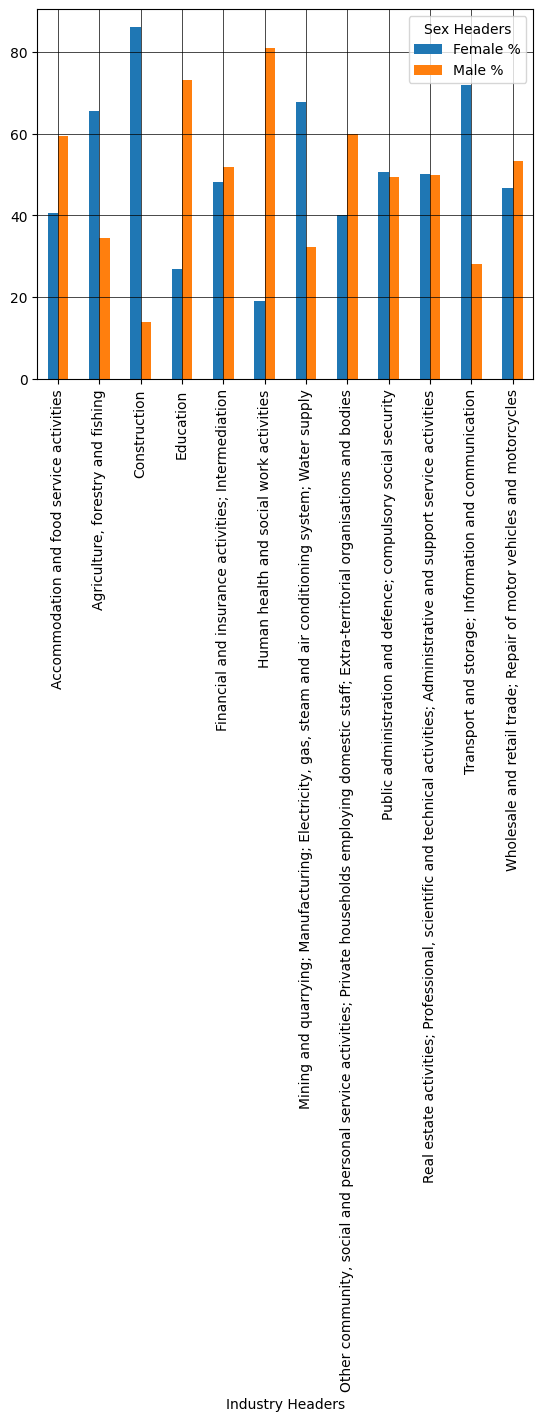

In [33]:
# Figure 4 - text representation adn bar chart

data_bar_chart(df_industry_sex, "Industry Headers", "Sex Headers")